# 17 — XGBoost v4 Model Training
## RentSignal — Data Architecture Phase 4

**Goal:** Retrain the rent prediction model on 2026 Apify data with unit-level spatial features.

**What's new vs v3:**
| Aspect | v3 (Kaggle) | v4 (Apify 2026) |
|--------|-------------|-----------------|
| Training data | 10,275 listings (2018-2019) | ~8,250 listings (2026) |
| Inflation hack | ×1.378 at prediction time | None needed (current data) |
| Spatial resolution | PLZ-level (18 features) | Unit-level (24 features) |
| New features | — | dist_cbd, dist_ubahn, count_cafe, count_restaurant, count_building, multi-scale NDVI/NDWI/NDBI |
| Total features | 37 | 43 |

**Output:**
- `models/xgboost_rent_v4.joblib` — trained model
- `models/shap_explainer_v4.joblib` — SHAP TreeExplainer
- `models/feature_encoder_v4.joblib` — OrdinalEncoder for categoricals
- `models/model_config.json` — updated config

In [2]:
import sys, json, hashlib, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
import joblib
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'

# Load all tables
units = pd.read_parquet(PROC_DIR / 'units.parquet')
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
spatial = pd.read_parquet(PROC_DIR / 'spatial_unit.parquet')

# Merge into training dataset
df = units.merge(listings[['unit_id', 'rent_sqm', 'baseRent']], on='unit_id')
df = df.merge(spatial.drop(columns=['coord_source']), on='unit_id', how='left')

print(f'Training dataset: {len(df):,} rows')
print(f'Target (rent_sqm): mean={df["rent_sqm"].mean():.2f}, median={df["rent_sqm"].median():.2f}')

Training dataset: 8,256 rows
Target (rent_sqm): mean=16.09, median=14.38


## 1. Feature Engineering

Define the feature set: 19 structural + 24 spatial = 43 features.

In [3]:
# --- Feature definitions ---

NUMERIC_FEATURES = [
    'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors',
    'thermalChar', 'sqm_per_room',
]

BINARY_FEATURES = [
    'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst',
]

CATEGORICAL_FEATURES = [
    'condition', 'interiorQual', 'typeOfFlat', 'heatingType',
    'building_era', 'bezirk',
]

SPATIAL_FEATURES = [
    # Distance features (7)
    'dist_cbd_m', 'dist_transit_m', 'dist_ubahn_m',
    'dist_park_m', 'dist_water_m', 'dist_school_m',
    # Count features (9)
    'count_food_500m', 'count_food_1000m',
    'count_restaurant_500m', 'count_restaurant_1000m',
    'count_cafe_500m',
    'count_shop_500m', 'count_shop_1000m',
    'count_transit_1000m',
    'count_building_200m',
    # Satellite multi-scale (9)
    'ndvi_100m', 'ndvi_250m', 'ndvi_500m',
    'ndwi_100m', 'ndwi_250m', 'ndwi_500m',
    'ndbi_100m', 'ndbi_250m', 'ndbi_500m',
]

ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES + SPATIAL_FEATURES
TARGET = 'rent_sqm'

print(f'Feature groups:')
print(f'  Numeric:     {len(NUMERIC_FEATURES)}')
print(f'  Binary:      {len(BINARY_FEATURES)}')
print(f'  Categorical: {len(CATEGORICAL_FEATURES)}')
print(f'  Spatial:     {len(SPATIAL_FEATURES)}')
print(f'  Total:       {len(ALL_FEATURES)}')

# Check all features exist
missing = [f for f in ALL_FEATURES if f not in df.columns]
if missing:
    print(f'\n  WARNING: Missing features: {missing}')
else:
    print(f'\n  All {len(ALL_FEATURES)} features present in dataset')

Feature groups:
  Numeric:     7
  Binary:      6
  Categorical: 6
  Spatial:     24
  Total:       43

  All 43 features present in dataset


In [4]:
# --- Prepare features ---

# Binary: ensure bool → int
for col in BINARY_FEATURES:
    df[col] = df[col].astype(int)

# Numeric: fill missing with median
for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    median_val = df[col].median()
    n_missing = df[col].isna().sum()
    if n_missing > 0:
        df[col] = df[col].fillna(median_val)
        print(f'  {col}: filled {n_missing} missing with median={median_val:.1f}')

# Spatial: fill missing with 0 (6 units without spatial features)
for col in SPATIAL_FEATURES:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    n_missing = df[col].isna().sum()
    if n_missing > 0:
        df[col] = df[col].fillna(0)
        print(f'  {col}: filled {n_missing} missing with 0')

# Categorical: fill missing with 'unknown', then encode
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna('unknown').astype(str)

# Fit OrdinalEncoder on categoricals
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[CATEGORICAL_FEATURES] = encoder.fit_transform(df[CATEGORICAL_FEATURES])

print(f'\nCategorical encoding:')
for i, col in enumerate(CATEGORICAL_FEATURES):
    cats = encoder.categories_[i]
    print(f'  {col}: {len(cats)} categories → {list(cats)[:8]}{"..." if len(cats) > 8 else ""}')

# Final feature matrix
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print(f'\nFeature matrix: {X.shape}')
print(f'Target: {len(y)} values, range [{y.min():.1f}, {y.max():.1f}]')
print(f'Any NaN in X: {X.isna().any().any()}')

  yearConstructed: filled 5652 missing with median=2016.0
  floor: filled 3818 missing with median=2.0
  numberOfFloors: filled 5534 missing with median=5.0
  thermalChar: filled 6540 missing with median=71.0
  dist_cbd_m: filled 6 missing with 0
  dist_transit_m: filled 6 missing with 0
  dist_ubahn_m: filled 6 missing with 0
  dist_park_m: filled 6 missing with 0
  dist_water_m: filled 6 missing with 0
  dist_school_m: filled 6 missing with 0
  count_food_500m: filled 6 missing with 0
  count_food_1000m: filled 6 missing with 0
  count_restaurant_500m: filled 6 missing with 0
  count_restaurant_1000m: filled 6 missing with 0
  count_cafe_500m: filled 6 missing with 0
  count_shop_500m: filled 6 missing with 0
  count_shop_1000m: filled 6 missing with 0
  count_transit_1000m: filled 6 missing with 0
  count_building_200m: filled 6 missing with 0
  ndvi_100m: filled 19 missing with 0
  ndvi_250m: filled 19 missing with 0
  ndvi_500m: filled 19 missing with 0
  ndwi_100m: filled 19 miss

## 2. Train/Test Split & Baseline

80/20 split (same as v3 for comparability). Seed=42.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

# Baseline: predict mean
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f'\nBaseline (predict mean):')
print(f'  R² = {baseline_r2:.4f}')
print(f'  RMSE = {baseline_rmse:.2f} €/m²')

Train: 6,604 samples
Test:  1,652 samples

Baseline (predict mean):
  R² = -0.0001
  RMSE = 7.79 €/m²


## 3. XGBoost Training

Using same hyperparameters as v3 as starting point, with early stopping on validation set.

In [6]:
# Split train into train + validation for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# XGBoost with same hyperparams as v3 + early stopping
model = xgb.XGBRegressor(
    n_estimators=1500,       # higher cap, early stopping will pick optimal
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,           # L1 regularization (new)
    reg_lambda=1.0,          # L2 regularization (new)
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse',
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Best validation RMSE: {model.best_score:.4f}')

[0]	validation_0-rmse:7.86058
[100]	validation_0-rmse:4.47971
[200]	validation_0-rmse:4.45883
[243]	validation_0-rmse:4.46350

Best iteration: 193
Best validation RMSE: 4.4551


## 4. Evaluation on Test Set

=== v4 Test Set Performance ===
  R²:   0.7083
  RMSE: 4.21 €/m²
  MAE:  3.07 €/m²

=== Comparison with v3 ===
  Metric    v3 (Kaggle+PLZ)  v4 (Apify+Unit)     Change
  R²                 0.7491           0.7083    -0.0408
  RMSE                 2.59             4.21      +1.62
  MAE                  1.70             3.07      +1.37


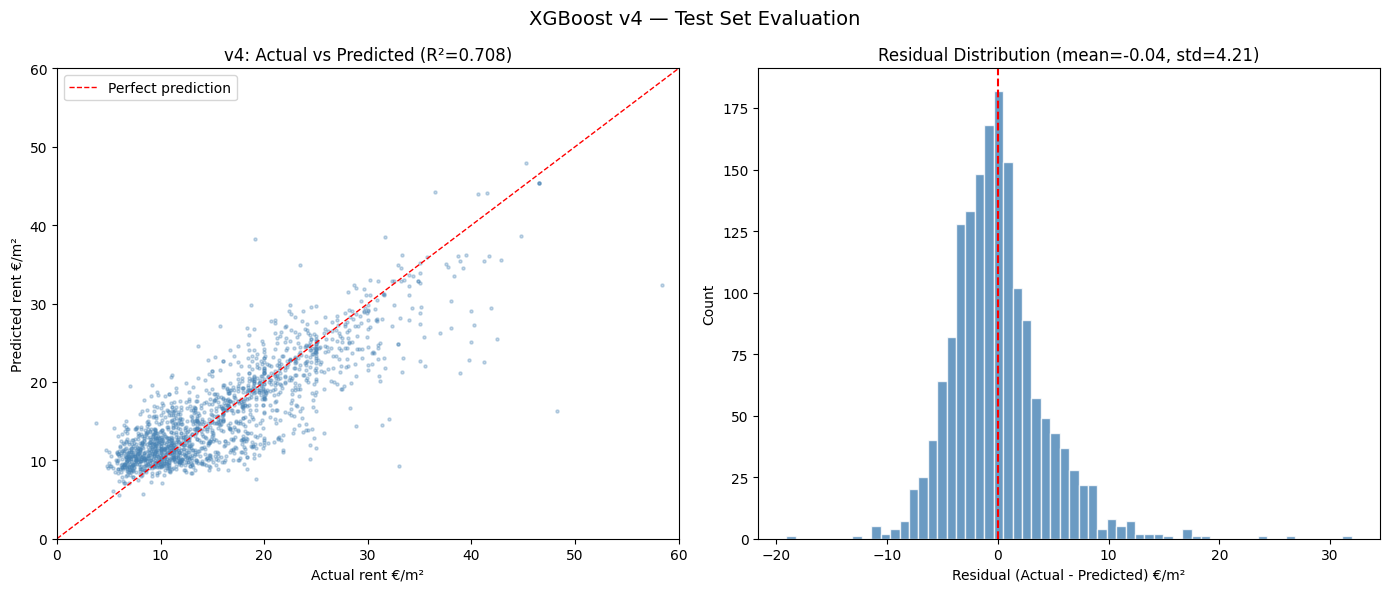

In [7]:
# Predict on held-out test set
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print('=== v4 Test Set Performance ===')
print(f'  R²:   {r2:.4f}')
print(f'  RMSE: {rmse:.2f} €/m²')
print(f'  MAE:  {mae:.2f} €/m²')
print()
print('=== Comparison with v3 ===')
print(f'  {"Metric":<8} {"v3 (Kaggle+PLZ)":>16} {"v4 (Apify+Unit)":>16} {"Change":>10}')
print(f'  {"R²":<8} {"0.7491":>16} {r2:>16.4f} {r2 - 0.7491:>+10.4f}')
print(f'  {"RMSE":<8} {"2.59":>16} {rmse:>16.2f} {rmse - 2.59:>+10.2f}')
print(f'  {"MAE":<8} {"1.70":>16} {mae:>16.2f} {mae - 1.70:>+10.2f}')

# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test, y_pred, s=5, alpha=0.3, c='steelblue')
ax.plot([0, 60], [0, 60], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual rent €/m²')
ax.set_ylabel('Predicted rent €/m²')
ax.set_title(f'v4: Actual vs Predicted (R²={r2:.3f})')
ax.legend()
ax.set_xlim(0, 60)
ax.set_ylim(0, 60)

# Residual distribution
ax = axes[1]
residuals = y_test - y_pred
ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual (Actual - Predicted) €/m²')
ax.set_ylabel('Count')
ax.set_title(f'Residual Distribution (mean={residuals.mean():.2f}, std={residuals.std():.2f})')

plt.suptitle('XGBoost v4 — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.show()

## 5. SHAP Feature Importance

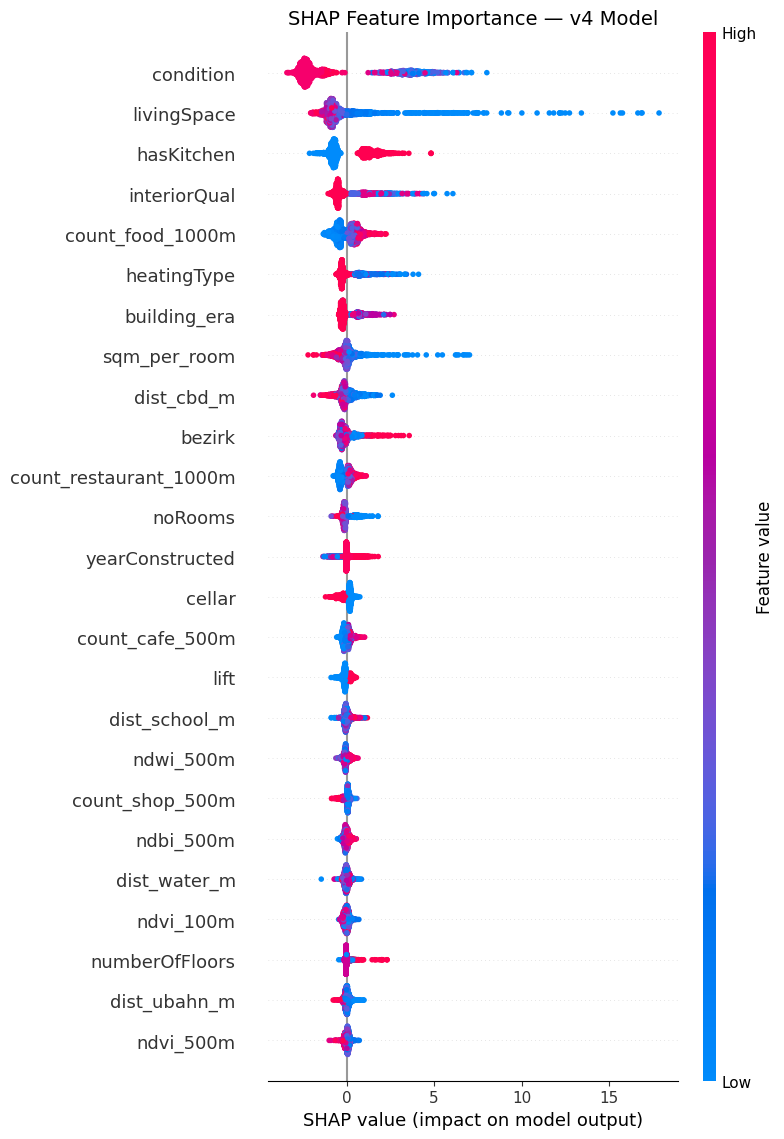

=== Top 20 Features by Mean |SHAP| ===
   1. condition                    2.561  [STRUCT]
   2. livingSpace                  1.264  [STRUCT]
   3. hasKitchen                   1.051  [STRUCT]
   4. interiorQual                 0.791  [STRUCT]
   5. count_food_1000m             0.530  [SPATIAL]
   6. heatingType                  0.494  [STRUCT]
   7. building_era                 0.429  [STRUCT]
   8. sqm_per_room                 0.400  [STRUCT]
   9. dist_cbd_m                   0.344  [SPATIAL]
  10. bezirk                       0.326  [STRUCT]
  11. count_restaurant_1000m       0.279  [SPATIAL]
  12. noRooms                      0.230  [STRUCT]
  13. yearConstructed              0.230  [STRUCT]
  14. cellar                       0.229  [STRUCT]
  15. count_cafe_500m              0.176  [SPATIAL]
  16. lift                         0.160  [STRUCT]
  17. dist_school_m                0.129  [SPATIAL]
  18. ndwi_500m                    0.125  [SPATIAL]
  19. count_shop_500m              0.

In [8]:
# SHAP analysis
explainer = shap.TreeExplainer(model)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Summary plot
fig, ax = plt.subplots(figsize=(10, 12))
shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES, show=False, max_display=25)
plt.title('SHAP Feature Importance — v4 Model', fontsize=14)
plt.tight_layout()
plt.show()

# Mean absolute SHAP values (global importance)
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({'feature': ALL_FEATURES, 'mean_abs_shap': mean_shap}).sort_values('mean_abs_shap', ascending=False)

print('=== Top 20 Features by Mean |SHAP| ===')
for i, (_, row) in enumerate(shap_df.head(20).iterrows()):
    group = 'SPATIAL' if row['feature'] in SPATIAL_FEATURES else 'STRUCT'
    print(f'  {i+1:>2}. {row["feature"]:<28} {row["mean_abs_shap"]:.3f}  [{group}]')

## 6. Ablation Study — Structural vs Spatial

Compare model performance with different feature sets to measure the contribution of unit-level spatial features.

In [9]:
# Ablation: train with structural-only vs structural+spatial
ablation_results = {}

feature_sets = {
    'structural_only': NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES,
    'structural + spatial': ALL_FEATURES,
}

for name, features in feature_sets.items():
    X_tr_abl = X_tr[features]
    X_val_abl = X_val[features]
    X_test_abl = X_test[features]
    
    m = xgb.XGBRegressor(
        n_estimators=1500, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
        early_stopping_rounds=50, eval_metric='rmse',
    )
    m.fit(X_tr_abl, y_tr, eval_set=[(X_val_abl, y_val)], verbose=0)
    
    pred = m.predict(X_test_abl)
    r2_abl = r2_score(y_test, pred)
    rmse_abl = np.sqrt(mean_squared_error(y_test, pred))
    ablation_results[name] = {'r2': r2_abl, 'rmse': rmse_abl, 'n_features': len(features), 'best_iter': m.best_iteration}

print('=== Ablation Study ===')
print(f'  {"Model":<30} {"Features":>8} {"R²":>8} {"RMSE":>8} {"Iters":>6}')
print(f'  {"-"*62}')
for name, res in ablation_results.items():
    print(f'  {name:<30} {res["n_features"]:>8} {res["r2"]:>8.4f} {res["rmse"]:>8.2f} {res["best_iter"]:>6}')

r2_struct = ablation_results['structural_only']['r2']
r2_full = ablation_results['structural + spatial']['r2']
print(f'\n  Spatial feature contribution: ΔR² = {r2_full - r2_struct:+.4f} ({100*(r2_full - r2_struct)/r2_struct:+.1f}% relative)')
print(f'  v3 spatial contribution was: ΔR² = +0.0243 (+3.4%)')
print(f'  v4 spatial contribution is:  ΔR² = {r2_full - r2_struct:+.4f} ({100*(r2_full - r2_struct)/r2_struct:+.1f}%)')

=== Ablation Study ===
  Model                          Features       R²     RMSE  Iters
  --------------------------------------------------------------
  structural_only                      19   0.6889     4.34    222
  structural + spatial                 43   0.7083     4.21    193

  Spatial feature contribution: ΔR² = +0.0193 (+2.8% relative)
  v3 spatial contribution was: ΔR² = +0.0243 (+3.4%)
  v4 spatial contribution is:  ΔR² = +0.0193 (+2.8%)


## 7. Save Model Artifacts

In [10]:
# Save model artifacts
joblib.dump(model, MODEL_DIR / 'xgboost_rent_v4.joblib')
joblib.dump(explainer, MODEL_DIR / 'shap_explainer_v4.joblib')
joblib.dump(encoder, MODEL_DIR / 'feature_encoder_v4.joblib')

# Update model_config.json
data_hash = hashlib.sha256(open(PROC_DIR / 'units.parquet', 'rb').read()).hexdigest()

config = {
    'model_version': 'v4.0.0',
    'trained_at': datetime.now().isoformat(),
    'data_source': 'apify_immoscout24_berlin_2026_03',
    'data_files': {
        'units': 'data/processed/units.parquet',
        'listings': 'data/processed/listings.parquet',
        'spatial_unit': 'data/processed/spatial_unit.parquet',
    },
    'data_file_sha256': data_hash,
    
    'inflation_factor': 1.0,
    'inflation_factor_active': False,
    'inflation_note': 'Trained on 2026 data — no inflation adjustment needed',
    
    'features': ALL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'binary_features': BINARY_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'spatial_features': SPATIAL_FEATURES,
    
    'spatial_level': 'unit',
    'spatial_note': 'Point-level OSM + multi-scale satellite (100m/250m/500m buffers)',
    
    'best_params': {
        'n_estimators': model.best_iteration,
        'max_depth': 8,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 5,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
    },
    
    'train_size': len(X_train),
    'test_size': len(X_test),
    
    'metrics': {
        'r2': round(r2, 4),
        'rmse': round(rmse, 4),
        'mae': round(mae, 4),
    },
    
    'spatial_improvement': {
        'r2_structural_only': round(ablation_results['structural_only']['r2'], 4),
        'r2_with_spatial': round(ablation_results['structural + spatial']['r2'], 4),
        'r2_delta': round(r2_full - r2_struct, 4),
        'r2_delta_pct': round(100 * (r2_full - r2_struct) / r2_struct, 2),
    },
    
    'v3_comparison': {
        'v3_r2': 0.7491,
        'v3_rmse': 2.59,
        'v4_r2': round(r2, 4),
        'v4_rmse': round(rmse, 4),
    },
    
    'artifacts': {
        'model': 'models/xgboost_rent_v4.joblib',
        'shap_explainer': 'models/shap_explainer_v4.joblib',
        'feature_encoder': 'models/feature_encoder_v4.joblib',
    },
}

with open(MODEL_DIR / 'model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('=== Artifacts Saved ===')
print(f'  xgboost_rent_v4.joblib')
print(f'  shap_explainer_v4.joblib')
print(f'  feature_encoder_v4.joblib')
print(f'  model_config.json (updated)')
print()
print('=== Phase 4 Complete ===')
print(f'  Model: XGBoost v4.0.0')
print(f'  R² = {r2:.4f} (v3 was 0.7491)')
print(f'  RMSE = {rmse:.2f} €/m² (v3 was 2.59)')
print(f'  Features: {len(ALL_FEATURES)} (v3 had 37)')
print(f'  Spatial: unit-level, 24 features (v3 had 18 PLZ-level)')
print(f'  Inflation: none (v3 used ×1.378)')
print()
print('=== All 4 Phases Complete! ===')

=== Artifacts Saved ===
  xgboost_rent_v4.joblib
  shap_explainer_v4.joblib
  feature_encoder_v4.joblib
  model_config.json (updated)

=== Phase 4 Complete ===
  Model: XGBoost v4.0.0
  R² = 0.7083 (v3 was 0.7491)
  RMSE = 4.21 €/m² (v3 was 2.59)
  Features: 43 (v3 had 37)
  Spatial: unit-level, 24 features (v3 had 18 PLZ-level)
  Inflation: none (v3 used ×1.378)

=== All 4 Phases Complete! ===
